# 04 · Self-attention — the heart of the Transformer

Each token looks around and asks: **"which other tokens matter to me?"**

> *"The cat sat because **it** was tired"* — the token `it` should attend strongly to `cat`,
> so the model resolves *it = cat*.

### Q / K / V — like a library lookup
From each token's vector we compute three vectors:

| | Meaning | Analogy |
|---|---|---|
| **Query (Q)** | what I'm looking for | my search request |
| **Key (K)** | what I advertise | each book's index card |
| **Value (V)** | my actual content | the book's text |

Then: `Attention(Q,K,V) = softmax(Q·Kᵀ / √dₖ) · V`
1. `Q · Kᵀ` — score every token pair (how well my query matches your key).
2. `/ √dₖ` then `softmax` — scale for stability, turn scores into weights that sum to 1.
3. multiply by `V` — output = weighted blend of everyone's values.

In [1]:
import numpy as np
np.random.seed(0)

def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x); return e / e.sum(axis=axis, keepdims=True)

def attention(Q, K, V, mask=None):
    d_k = Q.shape[-1]
    scores = Q @ K.swapaxes(-1, -2) / np.sqrt(d_k)   # (T, T) pairwise match scores
    if mask is not None:
        scores = np.where(mask, scores, -1e9)        # -inf on forbidden pairs -> ~0 after softmax
    weights = softmax(scores, axis=-1)               # each row sums to 1 = a distribution
    return weights @ V, weights                      # blend values by those weights

# 4 tokens, 8-dim. Random embeddings + random Q/K/V projections stand in for learned weights.
T, d = 4, 8
X = np.random.randn(T, d)
Wq, Wk, Wv = (np.random.randn(d, d) for _ in range(3))
Q, K, V = X @ Wq, X @ Wk, X @ Wv

out, w = attention(Q, K, V)
print("attention weights (row i = how much token i looks at each token):")
print(w.round(2))
assert np.allclose(w.sum(axis=-1), 1.0)   # every token's attention is a proper distribution
print("output shape:", out.shape, "(one blended vector per token)")

attention weights (row i = how much token i looks at each token):
[[0.   0.99 0.01 0.  ]
 [0.03 0.35 0.09 0.54]
 [0.   0.   1.   0.  ]
 [0.   0.93 0.07 0.  ]]
output shape: (4, 8) (one blended vector per token)


### Line by line
- `scores = Q @ K.T / sqrt(d_k)` — dot product = similarity. Dividing by `√dₖ` keeps scores
  from getting huge as dimension grows (which would make softmax nearly one-hot and kill
  gradients).
- `softmax(scores)` — each **row** becomes weights summing to 1: token i's "attention budget"
  spread across all tokens.
- `weights @ V` — each token's output is the weighted average of every token's Value.

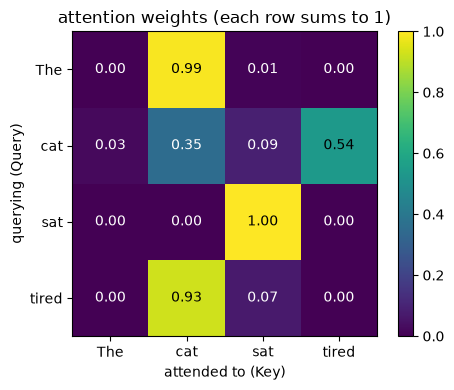

In [2]:
# Visual: the attention matrix. Row = querying token, column = attended token.
import matplotlib.pyplot as plt

labels = ["The", "cat", "sat", "tired"]
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(w, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(T)); ax.set_xticklabels(labels)
ax.set_yticks(range(T)); ax.set_yticklabels(labels)
ax.set_xlabel("attended to (Key)"); ax.set_ylabel("querying (Query)")
ax.set_title("attention weights (each row sums to 1)")
for i in range(T):
    for j in range(T):
        ax.text(j, i, f"{w[i,j]:.2f}", ha="center", va="center",
                color="white" if w[i,j] < 0.5 else "black")
fig.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

**Takeaway.** Attention = each token builds a weighted summary of the others, where the
weights come from Query·Key match. This is how context flows between words. (Weights here are
random; a trained model learns meaningful ones like *it → cat*.)

Next: **05 · causal masking** — stopping a token from peeking at the future.